In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip uninstall -y timesfm
!pip install -U git+https://github.com/google-research/timesfm.git

  Cloning https://github.com/google-research/timesfm.git to /tmp/pip-req-build-m_k6pily
  Running command git clone --filter=blob:none --quiet https://github.com/google-research/timesfm.git /tmp/pip-req-build-m_k6pily
  Encountered 4 file(s) that should have been pointers, but weren't:
        timesfm-forecasting/examples/anomaly-detection/output/anomaly_detection.png
        timesfm-forecasting/examples/covariates-forecasting/output/covariates_data.png
        timesfm-forecasting/examples/global-temperature/output/forecast_animation.gif
        timesfm-forecasting/examples/global-temperature/output/forecast_visualization.png
  Resolved https://github.com/google-research/timesfm.git to commit d720daa6786539c2566a44464fbda1019c0a82c0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for timesfm: filename=timesfm-2.0.0-py3-none-any.whl size=44486 sha256=e56c594608c426eb24c27cf611c23d01966

In [3]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    root_mean_squared_error = None

import timesfm

DATE_COL = "date"
ID_COL = "solar_ref_id"
TARGET_COL = "solar_gen_kwh"

COVARIATE_COLS = [
    "ALLSKY_SFC_SW_DWN",
    "T2M",
    "WS2M",
    "RH2M",
    "day_of_year",
    "month",
]

CONTEXT_START = "2023-01-01"
CONTEXT_END = "2024-12-31"

TEST_START = "2025-01-01"
TEST_END = "2025-12-31"

CONTEXT_START = pd.to_datetime(CONTEXT_START)
CONTEXT_END = pd.to_datetime(CONTEXT_END)

TEST_START = pd.to_datetime(TEST_START)
TEST_END = pd.to_datetime(TEST_END)

CONTEXT_LEN = (CONTEXT_END - CONTEXT_START).days + 1
PRED_LEN = (TEST_END - TEST_START).days + 1

print("CONTEXT_LEN:", CONTEXT_LEN)
print("PRED_LEN:", PRED_LEN)

QUANTILE_LEVELS = [0.1, 0.5, 0.9]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

CONTEXT_LEN: 731
PRED_LEN: 365
Device: cuda


# **Prepare benchmark data**

In [4]:
import time
import pandas as pd
import numpy as np

full_data_path = "/content/drive/MyDrive/TT/data/main/daily/main.csv"

full_data = pd.read_csv(full_data_path, parse_dates=["date"])
full_data = full_data.drop(columns=["lat", "long", "T_cell", "temp_factor"])
full_data["date"] = pd.to_datetime(full_data["date"])

full_data

,solar_ref_id,date,ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M,solar_gen_kwh,day_of_year,month
0,AUS_SOLAR_REF_000,2016-01-01,8.9544,31.15,4.20,40.78,42.557171,1,1
1,AUS_SOLAR_REF_000,2016-01-02,8.5466,26.56,4.61,53.99,41.505010,2,1
2,AUS_SOLAR_REF_000,2016-01-03,8.2236,26.15,2.78,55.57,40.121445,3,1
3,AUS_SOLAR_REF_000,2016-01-04,5.6350,25.23,3.16,58.72,28.261850,4,1
4,AUS_SOLAR_REF_000,2016-01-05,5.3940,24.70,3.66,59.91,27.166024,5,1
...,...,...,...,...,...,...,...,...,...
1826495,AUS_SOLAR_REF_499,2025-12-27,9.6631,19.30,2.33,41.20,47.725092,361,12
1826496,AUS_SOLAR_REF_499,2025-12-28,8.7079,21.64,3.20,37.60,43.015178,362,12
1826497,AUS_SOLAR_REF_499,2025-12-29,9.6110,24.35,1.99,34.56,46.593972,363,12
1826498,AUS_SOLAR_REF_499,2025-12-30,8.8459,27.43,1.90,27.50,42.693967,364,12


In [5]:
test_data = full_data[full_data['date'] >= "2025-01-01"]
test_data

,solar_ref_id,date,ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M,solar_gen_kwh,day_of_year,month
3288,AUS_SOLAR_REF_000,2025-01-01,6.9077,33.91,2.94,28.34,33.130762,1,1
3289,AUS_SOLAR_REF_000,2025-01-02,8.4636,34.23,3.80,31.01,39.934746,2,1
3290,AUS_SOLAR_REF_000,2025-01-03,8.8351,28.54,5.57,43.08,42.465017,3,1
3291,AUS_SOLAR_REF_000,2025-01-04,9.0682,25.44,5.62,49.62,44.007231,4,1
3292,AUS_SOLAR_REF_000,2025-01-05,9.1289,27.47,4.77,43.23,43.933737,5,1
...,...,...,...,...,...,...,...,...,...
1826495,AUS_SOLAR_REF_499,2025-12-27,9.6631,19.30,2.33,41.20,47.725092,361,12
1826496,AUS_SOLAR_REF_499,2025-12-28,8.7079,21.64,3.20,37.60,43.015178,362,12
1826497,AUS_SOLAR_REF_499,2025-12-29,9.6110,24.35,1.99,34.56,46.593972,363,12
1826498,AUS_SOLAR_REF_499,2025-12-30,8.8459,27.43,1.90,27.50,42.693967,364,12


In [6]:
context_data = full_data[(full_data['date'] >= "2023-01-01") & (full_data['date'] <= "2024-12-31")]
context_data

,solar_ref_id,date,ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M,solar_gen_kwh,day_of_year,month
2557,AUS_SOLAR_REF_000,2023-01-01,9.1733,25.61,5.55,45.88,44.443911,1,1
2558,AUS_SOLAR_REF_000,2023-01-02,8.5126,32.21,6.23,25.99,40.464449,2,1
2559,AUS_SOLAR_REF_000,2023-01-03,8.4670,34.70,6.61,17.99,39.875917,3,1
2560,AUS_SOLAR_REF_000,2023-01-04,8.3974,35.58,5.41,15.56,39.438571,4,1
2561,AUS_SOLAR_REF_000,2023-01-05,8.5397,35.16,4.59,17.12,40.117026,5,1
...,...,...,...,...,...,...,...,...,...
1826130,AUS_SOLAR_REF_499,2024-12-27,9.0422,23.97,4.07,39.92,44.137553,362,12
1826131,AUS_SOLAR_REF_499,2024-12-28,8.9806,20.70,2.78,38.84,44.405118,363,12
1826132,AUS_SOLAR_REF_499,2024-12-29,9.2892,22.96,2.24,45.36,45.410609,364,12
1826133,AUS_SOLAR_REF_499,2024-12-30,8.7276,25.67,1.64,40.74,42.454566,365,12


In [7]:
print("context_data:", context_data.shape)
print("test_data:", test_data.shape)

context_data: (365500, 9)
test_data: (182500, 9)


In [8]:
def prepare_df(df):
    df = df.copy()

    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df[ID_COL] = df[ID_COL].astype(str)

    numeric_cols = [TARGET_COL] + COVARIATE_COLS

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)

    return df


def filter_by_date_range(context_data, test_data):
    context_data = context_data[
        (context_data[DATE_COL] >= CONTEXT_START) &
        (context_data[DATE_COL] <= CONTEXT_END)
    ].copy()

    test_data = test_data[
        (test_data[DATE_COL] >= TEST_START) &
        (test_data[DATE_COL] <= TEST_END)
    ].copy()

    ctx_count = context_data.groupby(ID_COL)[DATE_COL].nunique()
    test_count = test_data.groupby(ID_COL)[DATE_COL].nunique()

    coverage = pd.DataFrame({
        "context_days": ctx_count,
        "test_days": test_count,
    }).fillna(0).astype(int)

    coverage["valid"] = (
        (coverage["context_days"] == CONTEXT_LEN) &
        (coverage["test_days"] == PRED_LEN)
    )

    valid_ids = coverage[coverage["valid"]].index.tolist()

    context_data = context_data[context_data[ID_COL].isin(valid_ids)].copy()
    test_data = test_data[test_data[ID_COL].isin(valid_ids)].copy()

    return context_data, test_data, coverage, valid_ids

context_data = prepare_df(context_data)
test_data = prepare_df(test_data)

context_data, test_data, coverage, valid_ids = filter_by_date_range(
    context_data,
    test_data,
)

print("CONTEXT_LEN:", CONTEXT_LEN)
print("PRED_LEN:", PRED_LEN)
print("context_data:", context_data.shape)
print("test_data:", test_data.shape)
print("valid series:", len(valid_ids))

display(coverage.head(20))

CONTEXT_LEN: 731
PRED_LEN: 365
context_data: (365500, 9)
test_data: (182500, 9)
valid series: 500


,context_days,test_days,valid
solar_ref_id,,,
AUS_SOLAR_REF_000,731,365,True
AUS_SOLAR_REF_001,731,365,True
AUS_SOLAR_REF_002,731,365,True
AUS_SOLAR_REF_003,731,365,True
AUS_SOLAR_REF_004,731,365,True
AUS_SOLAR_REF_005,731,365,True
AUS_SOLAR_REF_006,731,365,True
AUS_SOLAR_REF_007,731,365,True
AUS_SOLAR_REF_008,731,365,True


In [9]:
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + eps)
    ) * 100


def quantile_loss(y_true, y_pred_q, q):
    y_true = np.asarray(y_true, dtype=float)
    y_pred_q = np.asarray(y_pred_q, dtype=float)

    error = y_true - y_pred_q
    return np.mean(np.maximum(q * error, (q - 1) * error))


def evaluate_forecast(pred_df, test_df, model_name, benchmark_name):
    pred_df = pred_df.copy()
    test_df = test_df.copy()

    pred_df[DATE_COL] = pd.to_datetime(pred_df[DATE_COL])
    test_df[DATE_COL] = pd.to_datetime(test_df[DATE_COL])

    pred_df[ID_COL] = pred_df[ID_COL].astype(str)
    test_df[ID_COL] = test_df[ID_COL].astype(str)

    # Quan trọng: merge nguyên pred_df để giữ q0.1, q0.5, q0.9 nếu có
    merged = test_df[[ID_COL, DATE_COL, TARGET_COL]].merge(
        pred_df,
        on=[ID_COL, DATE_COL],
        how="inner",
    )

    if len(merged) == 0:
        raise ValueError(
            f"Không match được dòng nào cho {model_name} - {benchmark_name}"
        )

    y_true = merged[TARGET_COL].to_numpy()
    y_pred = merged["y_pred"].to_numpy()

    mse = mean_squared_error(y_true, y_pred)

    metrics = {
        "model": model_name,
        "benchmark": benchmark_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": mse ** 0.5,
        "MAPE": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "sMAPE": smape(y_true, y_pred),
        "n_points": len(merged),
        "n_series": merged[ID_COL].nunique(),
    }

    if "q0.1" in merged.columns:
        metrics["QL_0.1"] = quantile_loss(
            y_true,
            merged["q0.1"].to_numpy(),
            0.1,
        )

    if "q0.5" in merged.columns:
        metrics["QL_0.5"] = quantile_loss(
            y_true,
            merged["q0.5"].to_numpy(),
            0.5,
        )

    if "q0.9" in merged.columns:
        metrics["QL_0.9"] = quantile_loss(
            y_true,
            merged["q0.9"].to_numpy(),
            0.9,
        )

    return metrics, merged

# **Load model and predict**

In [16]:
torch.set_float32_matmul_precision("high")

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch",
)

model.compile(
    timesfm.ForecastConfig(
        max_context=max(1024, CONTEXT_LEN),
        max_horizon=max(512, PRED_LEN),
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
        return_backcast=True,
    )
)

print("TimesFM 2.5 PyTorch loaded with return_backcast=True")

TimesFM 2.5 PyTorch loaded with return_backcast=True


In [17]:
# target only
def extract_timesfm_quantiles(quantile_forecast, n):
    """
    TimesFM có thể trả quantile_forecast dạng horizon x num_quantiles.
    Hàm này cố gắng lấy q0.1, q0.5, q0.9 nếu có.
    """
    if quantile_forecast is None:
        return {}

    q = np.asarray(quantile_forecast)

    out = {}

    if q.ndim == 2 and q.shape[1] >= 10:
        out["q0.1"] = q[:n, 1]
        out["q0.5"] = q[:n, 5]
        out["q0.9"] = q[:n, 9]

    elif q.ndim == 2 and q.shape[1] >= 9:
        out["q0.1"] = q[:n, 0]
        out["q0.5"] = q[:n, 4]
        out["q0.9"] = q[:n, 8]

    return out


def run_timesfm25_target_only(context_data, test_data):
    start = time.time()

    all_preds = []

    for sid, g_ctx in context_data.groupby(ID_COL):
        g_ctx = g_ctx.sort_values(DATE_COL)
        g_test = (
            test_data[test_data[ID_COL] == sid]
            .sort_values(DATE_COL)
            .copy()
        )

        if len(g_ctx) < CONTEXT_LEN or len(g_test) != PRED_LEN:
            continue

        context = g_ctx[TARGET_COL].astype(float).to_numpy()

        point_forecast, quantile_forecast = model.forecast(
            inputs=[context],
            horizon=PRED_LEN,
        )

        y_pred = np.asarray(point_forecast[0])[:len(g_test)]

        tmp = pd.DataFrame({
            ID_COL: sid,
            DATE_COL: g_test[DATE_COL].to_numpy(),
            "y_pred": y_pred,
        })

        q_dict = extract_timesfm_quantiles(
            quantile_forecast[0] if quantile_forecast is not None else None,
            len(g_test),
        )

        for k, v in q_dict.items():
            tmp[k] = v

        all_preds.append(tmp)

    if len(all_preds) == 0:
        raise ValueError("TimesFM target-only không tạo được prediction nào.")

    pred_df = pd.concat(all_preds, ignore_index=True)
    runtime = time.time() - start

    return pred_df, runtime

timesfm_target_pred, timesfm_target_runtime = run_timesfm25_target_only(
    context_data,
    test_data,
)

timesfm_target_metrics, timesfm_target_merged = evaluate_forecast(
    pred_df=timesfm_target_pred,
    test_df=test_data,
    model_name="TimesFM-2.5-PyTorch",
    benchmark_name="target_only",
)

timesfm_target_metrics["runtime_seconds"] = timesfm_target_runtime

display(timesfm_target_pred.head())
timesfm_target_metrics

,solar_ref_id,date,y_pred,q0.1,q0.5,q0.9
0,AUS_SOLAR_REF_000,2025-01-01,21.928978,21.928978,21.928978,21.928978
1,AUS_SOLAR_REF_000,2025-01-02,21.928978,21.928978,21.928978,21.928978
2,AUS_SOLAR_REF_000,2025-01-03,21.928978,21.928978,21.928978,21.928978
3,AUS_SOLAR_REF_000,2025-01-04,21.928978,21.928978,21.928978,21.928978
4,AUS_SOLAR_REF_000,2025-01-05,21.928978,21.928978,21.928978,21.928978


{'model': 'TimesFM-2.5-PyTorch',
 'benchmark': 'target_only',
 'MAE': 8.438384779212623,
 'RMSE': 10.657237243619129,
 'MSE': 113.57670566678266,
 'MAPE': 35.052027760909844,
 'sMAPE': np.float64(34.41628095719767),
 'n_points': 182500,
 'n_series': 500,
 'runtime_seconds': 234.81841707229614}

In [18]:
# target + covariates
def run_timesfm25_target_future_covariates(context_data, test_data):
    if not hasattr(model, "forecast_with_covariates"):
        raise AttributeError(
            "Model timesfm hiện tại không có forecast_with_covariates(). "
            "Hãy kiểm tra lại version timesfm."
        )

    start = time.time()
    all_preds = []

    for sid, g_ctx in context_data.groupby(ID_COL):
        g_ctx = g_ctx.sort_values(DATE_COL).copy()

        g_test = (
            test_data[test_data[ID_COL] == sid]
            .sort_values(DATE_COL)
            .copy()
        )

        if len(g_ctx) < CONTEXT_LEN or len(g_test) != PRED_LEN:
            continue

        context = g_ctx[TARGET_COL].astype(float).to_numpy()

        dynamic_numerical_covariates = {}

        for cov in COVARIATE_COLS:
            past_cov = g_ctx[cov].astype(float).to_numpy()
            future_cov = g_test[cov].astype(float).to_numpy()

            # TimesFM forecast_with_covariates cần chuỗi covariate gồm:
            # past covariates + future covariates
            # độ dài = len(context) + prediction_length
            cov_values = np.concatenate([past_cov, future_cov])

            dynamic_numerical_covariates[cov] = [cov_values]

        point_forecast, quantile_forecast = model.forecast_with_covariates(
            inputs=[context],
            dynamic_numerical_covariates=dynamic_numerical_covariates,
            dynamic_categorical_covariates={},
            static_numerical_covariates={},
            static_categorical_covariates={},
            xreg_mode="xreg + timesfm",
            normalize_xreg_target_per_input=True,
            ridge=0.0,
            max_rows_per_col=0,
            force_on_cpu=False,
        )

        y_pred = np.asarray(point_forecast[0])[:len(g_test)]

        tmp = pd.DataFrame({
            ID_COL: sid,
            DATE_COL: g_test[DATE_COL].to_numpy(),
            "y_pred": y_pred,
        })

        q_dict = extract_timesfm_quantiles(
            quantile_forecast[0] if quantile_forecast is not None else None,
            len(g_test),
        )

        for k, v in q_dict.items():
            tmp[k] = v

        all_preds.append(tmp)

    if len(all_preds) == 0:
        raise ValueError(
            "TimesFM target + future covariates không tạo được prediction nào. "
            "Hãy kiểm tra CONTEXT_LEN, PRED_LEN và số ngày của từng solar_ref_id."
        )

    pred_df = pd.concat(all_preds, ignore_index=True)
    runtime = time.time() - start

    return pred_df, runtime

timesfm_cov_pred, timesfm_cov_runtime = run_timesfm25_target_future_covariates(
    context_data,
    test_data,
)

timesfm_cov_metrics, timesfm_cov_merged = evaluate_forecast(
    pred_df=timesfm_cov_pred,
    test_df=test_data,
    model_name="TimesFM-2.5-PyTorch",
    benchmark_name="target_future_covariates",
)

timesfm_cov_metrics["runtime_seconds"] = timesfm_cov_runtime

display(timesfm_cov_pred.head())
timesfm_cov_metrics

,solar_ref_id,date,y_pred,q0.1,q0.5,q0.9
0,AUS_SOLAR_REF_000,2025-01-01,32.962157,32.650526,32.962157,33.248796
1,AUS_SOLAR_REF_000,2025-01-02,40.258497,39.910183,40.258497,40.575641
2,AUS_SOLAR_REF_000,2025-01-03,42.577948,42.211236,42.577948,42.909102
3,AUS_SOLAR_REF_000,2025-01-04,43.991850,43.619854,43.991850,44.330256
4,AUS_SOLAR_REF_000,2025-01-05,44.060579,43.691284,44.060579,44.404673


{'model': 'TimesFM-2.5-PyTorch',
 'benchmark': 'target_future_covariates',
 'MAE': 0.19599574368860534,
 'RMSE': 0.28133120552170154,
 'MSE': 0.07914724720029388,
 'MAPE': 1.0666973073769979,
 'sMAPE': np.float64(1.038168194225741),
 'n_points': 182500,
 'n_series': 500,
 'runtime_seconds': 230.50522899627686}

# **Benchmark**

In [19]:
timesfm_target_pred.to_csv("/content/drive/MyDrive/TT/benchmark_results/timesfm_target_only_pred.csv", index=False)
timesfm_cov_pred.to_csv("/content/drive/MyDrive/TT/benchmark_results/timesfm_future_cov_pred.csv", index=False)

timesfm_metrics = pd.DataFrame([
    timesfm_target_metrics,
    timesfm_cov_metrics,
])

display(timesfm_metrics)

timesfm_metrics.to_csv("/content/drive/MyDrive/TT/benchmark_results/timesfm_metrics.csv", index=False)

print("Saved:")
print("- timesfm_target_only_pred.csv")
print("- timesfm_future_cov_pred.csv")
print("- timesfm_metrics.csv")

,model,benchmark,MAE,RMSE,MSE,MAPE,sMAPE,n_points,n_series,runtime_seconds
0,TimesFM-2.5-PyTorch,target_only,8.438385,10.657237,113.576706,35.052028,34.416281,182500,500,234.818417
1,TimesFM-2.5-PyTorch,target_future_covariates,0.195996,0.281331,0.079147,1.066697,1.038168,182500,500,230.505229


Saved:
- timesfm_target_only_pred.csv
- timesfm_future_cov_pred.csv
- timesfm_metrics.csv


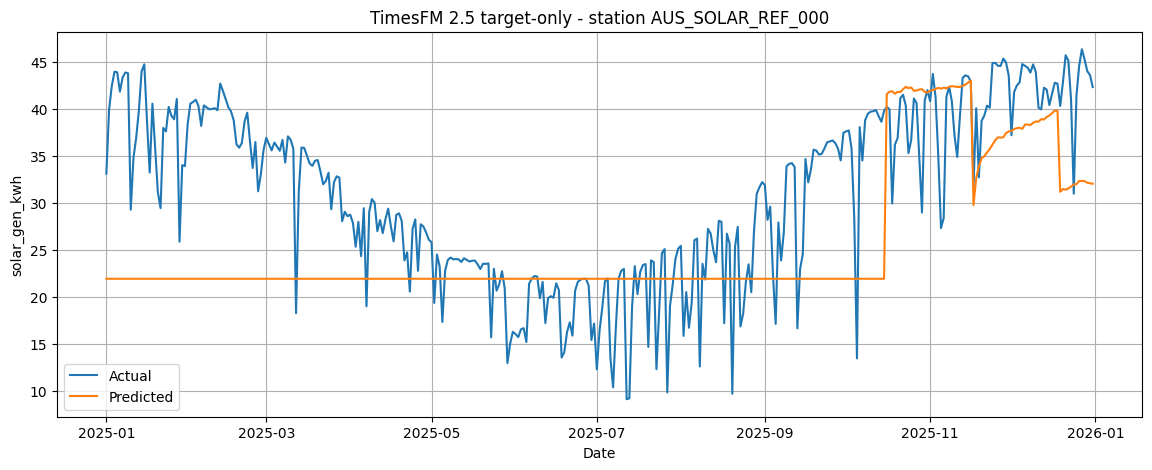

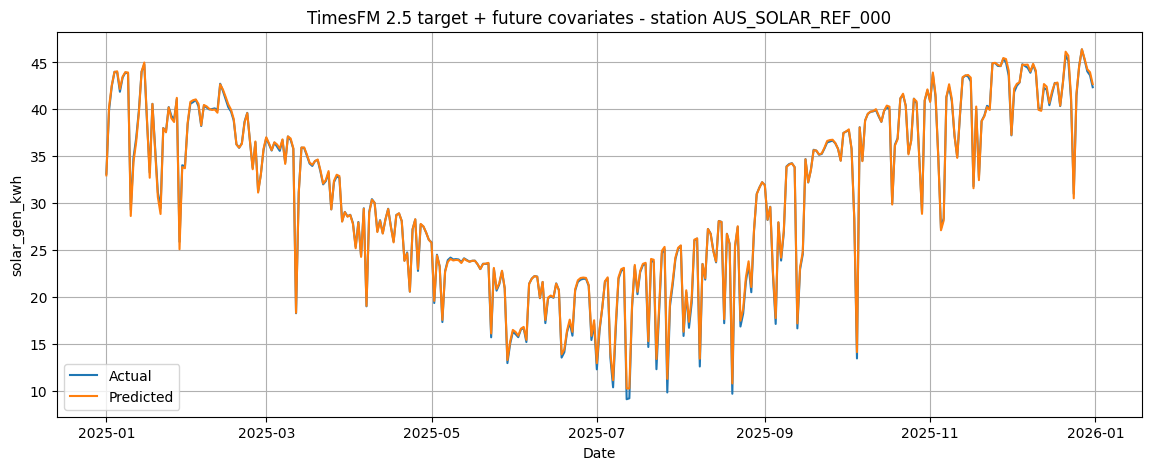

In [20]:
import matplotlib.pyplot as plt

def plot_forecast_for_station(pred_df, test_df, station_id, title):
    station_id = str(station_id)

    pred_g = pred_df[pred_df[ID_COL] == station_id].sort_values(DATE_COL)
    test_g = test_df[test_df[ID_COL] == station_id].sort_values(DATE_COL)

    merged = test_g[[DATE_COL, TARGET_COL]].merge(
        pred_g[[DATE_COL, "y_pred"]],
        on=DATE_COL,
        how="inner",
    )

    plt.figure(figsize=(14, 5))
    plt.plot(merged[DATE_COL], merged[TARGET_COL], label="Actual")
    plt.plot(merged[DATE_COL], merged["y_pred"], label="Predicted")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.grid(True)
    plt.show()


sample_station = valid_ids[0]

plot_forecast_for_station(
    pred_df=timesfm_target_pred,
    test_df=test_data,
    station_id=sample_station,
    title=f"TimesFM 2.5 target-only - station {sample_station}",
)

plot_forecast_for_station(
    pred_df=timesfm_cov_pred,
    test_df=test_data,
    station_id=sample_station,
    title=f"TimesFM 2.5 target + future covariates - station {sample_station}",
)